In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. PATHS (Update this to where your TrashNet folder is in Drive)
DATASET_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/models/waste_classifier_v1.h5'

# 2. HYPERPARAMETERS
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7 # glass, paper, cardboard, plastic, metal, trash - CORRECTED TO 2 BASED ON GENERATOR OUTPUT

# 3. DATA AUGMENTATION
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 4. MODEL SETUP
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. TRAINING WITH EARLY STOPPING
# If the model stops getting better, it stops training automatically
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("Starting Training on Colab GPU...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

# 6. SAVE TO DRIVE
model.save(MODEL_SAVE_PATH)
print(f"Model successfully saved to: {MODEL_SAVE_PATH}")

Found 12077 images belonging to 7 classes.
Found 3016 images belonging to 7 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Training on Colab GPU...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 4098s 11s/step - accuracy: 0.8112 - loss: 0.6687 - val_accuracy: 0.9108 - val_loss: 0.2491
Epoch 2/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 236s 623ms/step - accuracy: 0.9120 - loss: 0.2681 - val_accuracy: 0.9314 - val_loss: 0.2009
Epoch 3/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 232s 615ms/step - accuracy: 0.9272 - loss: 0.2144 - val_accuracy: 0.9373 - val_loss: 0.1817
Epoch 4/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 230s 608ms/step - accuracy: 0.9403 - loss: 0.1787 - val_accuracy: 0.9360 - val_loss: 0.1722
Epoch 5/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 228s 605ms/step - accuracy: 0.9444 - loss: 0.1649 - val_accuracy: 0.9387 - val_loss: 0.1665
Epoch 6/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 229s 606ms/step - accuracy: 0.9494 - loss: 0.1533 - val_accuracy: 0.9393 - val_loss: 0.1724
Epoch 7/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 229s 607ms/step - accuracy: 0.9516 - loss: 0.1463 - val_accuracy: 0.9380 - val_loss: 0.1585
Epoch 8/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 233s 617ms/step - accuracy: 0.9521 - 

Model successfully saved to: /content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/models/waste_classifier_v1.h5


📤 Upload images to test your model's intelligence...


Saving plastic8.jpg to plastic8.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


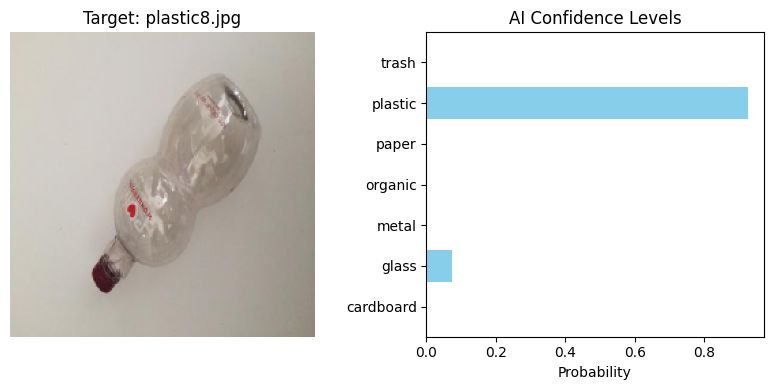

--------------------------------------------------
RESULT: PLASTIC (92.42% Confidence)
Category: RECYCLABLE
Action  : Check for recycling symbol. Remove caps and crush the bottle.
Bin     : BLUE BIN
--------------------------------------------------



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

# The exact order the generator used (alphabetical)
LABELS = ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']

def test_and_debug():
    print("📤 Upload images to test your model's intelligence...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 1. Prepare Image
        img = image.load_img(fn, target_size=(224, 224))
        x = image.img_to_array(img) / 255.0
        x = np.expand_dims(x, axis=0)

        # 2. Get Raw Predictions
        predictions = model.predict(x)[0]
        max_idx = np.argmax(predictions)
        confidence = predictions[max_idx] * 100

        # 3. Display Image and Results
        plt.figure(figsize=(8, 4))

        # Show the image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Target: {fn}")

        # Show Probability Bar Chart
        plt.subplot(1, 2, 2)
        y_pos = np.arange(len(LABELS))
        plt.barh(y_pos, predictions, color='skyblue')
        plt.yticks(y_pos, LABELS)
        plt.xlabel('Probability')
        plt.title('AI Confidence Levels')

        plt.tight_layout()
        plt.show()

        # 4. The "Hira" Logic Output (Text Based)
        print("-" * 50)
        print(f"RESULT: {LABELS[max_idx].upper()} ({confidence:.2f}% Confidence)")

        # This is where we verify your requested logic
        if confidence < 60:
            print("⚠️ DEBUG NOTE: Low confidence. The model might be confused.")

        # Logic display
        info = get_hira_guidance(LABELS[max_idx]) # Using the function from before
        print(f"Category: {info['lifecycle']}")
        print(f"Action  : {info['action']}")
        print(f"Warning : {info['safety']}")
        print(f"Bin     : {info['bin']}")
        print("-" * 50 + "\n")

# Run the debugger
test_and_debug()